In [ ]:
# 환경 설정 및 라이브러리 설치
!pip install -q openai langchain langchain-openai langchain-community faiss-cpu \
    rank_bm25 pandas numpy matplotlib gradio python-dotenv tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
pip install --upgrade pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 70.2 MB/s eta 0:00:00


In [ ]:
import os, io, base64, re, json, math
from pathlib import Path
from typing import List, Optional, Literal
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import fitz  # PyMuPDF
from PIL import Image
from pydantic import BaseModel, Field
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
# from dotenv import load_dotenv
# load_dotenv()
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
llm    = ChatOpenAI(model="gpt-4o-mini")
vision = ChatOpenAI(model="gpt-4o-mini", max_tokens=500)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
SAMPLE_DIR = Path("/content/drive/MyDrive/Colab Notebooks/2026-05-21 LLM 교육과정 실습/samples")

In [ ]:
IMAGE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/data/images')

In [ ]:
PDF_BUSINESS = SAMPLE_DIR / "business_report.pdf"

In [ ]:
doc = fitz.open(PDF_BUSINESS)

In [ ]:
page = doc[0]
blocks = [b for b in page.get_text('blocks') if b[4].strip()]

In [ ]:
len(blocks)

12

In [ ]:
blocks[0]

(128.25779724121094,
 61.01287078857422,
 467.0177917480469,
 94.06086730957031,
 '2024 Annual Business Report\n',
 0,
 0)

In [ ]:
blocks[0][4]

'2024 Annual Business Report\n'

In [ ]:
tables = page.find_tables().tables

Consider using the pymupdf_layout package for a greatly improved page layout analysis.


In [ ]:
df = tables[0].to_pandas()

In [ ]:
df

,Metric,2024,2023,Change (%)
0,Revenue ($B),2.80,2.28,+23%
1,Net Income ($M),420,310,+35%
2,Operating Margin,18.5%,15.2%,+3.3pp
3,R&D Spending ($M),580,490,+18%
4,Employees,"12,500","10,200",+23%


In [ ]:
image = page.get_images(full = True)

In [ ]:
len(image)

0

In [ ]:
image

[]

In [ ]:
doc.close() # 메모리 반환

# 2차시 시작

In [ ]:
def extract_text_blocks(pdf_path):
  out = []
  doc = fitz.open(pdf_path)
  src = Path(pdf_path).name
  for pi, page in enumerate(doc, 1):
    for b in page.get_text('blocks'):
      txt = b[4].strip()
      if len(txt) >= 20:
        out.append({'type': 'text', 'content' : txt, 'metadata': {'source': src, 'page': pi}})
  doc.close()
  return out

In [ ]:
blocks = extract_text_blocks(PDF_BUSINESS)
blocks

[{'type': 'text',
  'content': '2024 Annual Business Report',
  'metadata': {'source': 'business_report.pdf', 'page': 1}},
 {'type': 'text',
  'content': 'TechCorp International Inc.',
  'metadata': {'source': 'business_report.pdf', 'page': 1}},
 {'type': 'text',
  'content': "This report presents TechCorp International's financial performance for fiscal year 2024.\nThe company achieved record revenue of $2.8 billion, representing a 23% year-over-year\ngrowth. Our AI and cloud services division drove the majority of this growth, contributing\n65% of total revenue.",
  'metadata': {'source': 'business_report.pdf', 'page': 1}},
 {'type': 'text',
  'content': 'Key strategic initiatives including the acquisition of DataFlow Systems and expansion into\nthe Asia-Pacific market have positioned the company for sustained growth in 2025 and\nbeyond.',
  'metadata': {'source': 'business_report.pdf', 'page': 1}},
 {'type': 'text',
  'content': 'Financial Highlights',
  'metadata': {'source': 'busi

In [ ]:
# 실습, 테이블 추출
def extract_tables(pdf_path):
    out = []
    doc = fitz.open(pdf_path)
    for pi, page in enumerate(doc):
        tables = page.find_tables().tables
        for table in tables:
            rows = table.extract()
            txt = "\n".join([
                " | ".join([str(c) if c else "" for c in row])
                for row in rows
            ])

            out.append({'type': 'table', 'content': txt,
                'metadata': {
                    'source': pdf_path,
                    'page': pi + 1,
                    'shape': (table.row_count, table.col_count)
                }
            })

    return out

In [ ]:
# 실습, 테이블 추출
def extract_tables(pdf_path):
    out = []
    doc = fitz.open(pdf_path)
    src = Path(pdf_path).name
    for pi, page in enumerate(doc):
        for table in page.find_tables().tables: # find_tables()는 10주차 프로젝트에 있는 함수
            df = table.to_pandas()
            md_str = df.to_markdown(index = False)
            out.append({'type': 'table', 'content': md_str,
                'metadata': {
                    'source': src,
                    'page': pi + 1,
                    'shape': (table.row_count, table.col_count)
                }
            })

    return out

In [ ]:
# 아래 클래스에서 필요한 함수
def build_vision_message(text: str, images: list, detail: str = 'auto') -> HumanMessage:
  content = [{'type': 'text', 'text': text}]

  for img in images:
    uri = image_to_data_uri(img)
    content.append({'type':'image_url', 'image_url': {'url': uri, 'detail':detail}})

  return HumanMessage(content = content)

def image_to_data_uri(image_or_path) -> str:
    if isinstance(image_or_path, (str, Path)):
        img = Image.open(image_or_path)
    else:
        img = image_or_path
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return f"data:image/png;base64,{base64.b64encode(buf.getvalue()).decode()}"

In [ ]:
class BarPoint(BaseModel): # 차트를 복원하는 pydantic class
  label : str = Field(description = 'x축 라벨')
  value : float = Field(description = '추정 막대 높이')

class ChartData(BaseModel):
  title: str
  y_unit : str = Field(description = 'y축 단위 (예: KRW)')
  points : List[BarPoint]

def restore_chart(image) -> ChartData:
  msg = build_vision_message('이 막대 차트의 각 막대 라벨과 추정 값을 추출하세요. y축 단위도 포함하세요,', [image], detail = 'high')
  return vision.with_structured_output(ChartData).invoke([msg]) # 랭체인에서도 썼었음. vision 이란건 LLM 객체임



In [ ]:
chart = restore_chart(IMAGE_DIR / 'chart_monthly_sales.png')

In [ ]:
chart

ChartData(title='Monthly Sales', y_unit='Sales (units)', points=[BarPoint(label='Jan', value=120.0), BarPoint(label='Feb', value=185.0), BarPoint(label='Mar', value=150.0), BarPoint(label='Apr', value=210.0), BarPoint(label='May', value=175.0), BarPoint(label='Jun', value=230.0)])

In [ ]:
for p in chart.points:
  print(p.label, p.value)

Jan 120.0
Feb 185.0
Mar 150.0
Apr 210.0
May 175.0
Jun 230.0


In [ ]:
import matplotlib.pyplot as plt
EQ_PATH = IMAGE_DIR / '_eq_gauss.png'
fig, ax = plt.subplots(figsize=(5, 1.5))
ax.axis("off")
ax.text(0.5, 0.5, r"$\int_{0}^{\infty} e^{-x^{2}}\, dx = \frac{\sqrt{\pi}}{2}$",
        ha="center", va="center", fontsize=22)
fig.savefig(EQ_PATH, dpi=150, bbox_inches="tight")
plt.close(fig)

$\int_{0}^{\infty} e^{-x^{2}}\, dx = \frac{\sqrt{\pi}}{2}$

In [ ]:
class LatexExtract(BaseModel):
  latex : str = Field(description = 'LaTex 코드 ($ 기호 제외)')
  meaning : str = Field(description = '수식 의미를 한국어 1문장')

def extract_latex(image) -> LatexExtract: # 해당 데이터 포맷으로 답을 받겠다는 것
  # 이미지를 뽑아서 LaTex 형태로 반환하는 것

  return

In [ ]:
def extract_latex(image) -> LatexExtract:
    with open(image, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")

    msg = llm.with_structured_output(LatexExtract).invoke([
        HumanMessage(content=[
            {"type": "text", "text": "이미지의 수식을 LaTex으로 추출하고 의미를 설명하세요."},
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}}
        ])
    ])

    return msg

In [ ]:
# 강사님 코드
def extract_latex(image) -> LatexExtract:
  msg = build_vision_message("이미지의 수식을 LaTex으로(\$ 기호 제외) 추출하고 의미를 설명하세요." , [image], detail = 'high')
  return vision.with_structured_output(LatexExtract).invoke([msg])

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_2578/3034364673.py:3: SyntaxWarning: invalid escape sequence '\$'
  msg = build_vision_message("이미지의 수식을 LaTex으로(\$ 기호 제외) 추출하고 의미를 설명하세요." , [image], detail = 'high')


In [ ]:
extract_latex(EQ_PATH).latex

'\\int_{0}^{\\infty} e^{-x^{2}} \\, dx = \\frac{\\sqrt{\\pi}}{2}'

In [ ]:
def sanity_check_chart(chart : ChartData) -> dict:
  issues = []

  if not chart.points:
    return {'valid' : False, 'issues' : ['empty_points']}

  labels = [p.label for p in chart.points]
  values = [p.value for p in chart.points]

  if len(set(labels)) != len(labels): # 즉 중복되는 라벨 확인
    issues.append('duplicate_labels')

  if any(v < 0 for v in values):
    issues.append('negative_values')

  pos = [v for v in values if v>0]
  if pos and max(pos) / max(min(pos), 0.01) > 100: # min과 max의 비율이 100배 이상 난다면 의심
    issues.append('extreme_value_range')

  return {'valid': len(issues) == 0, 'issues': issues}


In [ ]:
elements = extract_text_blocks(PDF_BUSINESS) + extract_tables(PDF_BUSINESS)

In [ ]:
len(elements)

34

In [ ]:
elements[:5]

[{'type': 'text',
  'content': '2024 Annual Business Report',
  'metadata': {'source': 'business_report.pdf', 'page': 1}},
 {'type': 'text',
  'content': 'TechCorp International Inc.',
  'metadata': {'source': 'business_report.pdf', 'page': 1}},
 {'type': 'text',
  'content': "This report presents TechCorp International's financial performance for fiscal year 2024.\nThe company achieved record revenue of $2.8 billion, representing a 23% year-over-year\ngrowth. Our AI and cloud services division drove the majority of this growth, contributing\n65% of total revenue.",
  'metadata': {'source': 'business_report.pdf', 'page': 1}},
 {'type': 'text',
  'content': 'Key strategic initiatives including the acquisition of DataFlow Systems and expansion into\nthe Asia-Pacific market have positioned the company for sustained growth in 2025 and\nbeyond.',
  'metadata': {'source': 'business_report.pdf', 'page': 1}},
 {'type': 'text',
  'content': 'Financial Highlights',
  'metadata': {'source': 'busi

In [ ]:
docs = [Document(page_content = e['content'], metadata = {**e['metadata'], 'element_type ': e['type']}) for e in elements[:30]]

In [ ]:
vs = FAISS.from_documents(docs, embeddings)

In [ ]:
vs.similarity_search('revenue')

[Document(id='b7a0c5c5-e2b8-4427-b279-5284176a2805', metadata={'source': 'business_report.pdf', 'page': 1, 'element_type ': 'text'}, page_content='Revenue ($B)\n2.80\n2.28\n+23%'),
 Document(id='74c54b52-c873-42cd-ac59-53b4590d2d93', metadata={'source': 'business_report.pdf', 'page': 2, 'element_type ': 'text'}, page_content='Revenue of $700M (+12% YoY). Our flagship ERP and CRM solutions continued to gain\nmarket share in the mid-market segment. Annual recurring revenue (ARR) grew to $650M.'),
 Document(id='ae9ff50c-0c54-4c4d-bbfd-43ae30bb7012', metadata={'source': 'business_report.pdf', 'page': 2, 'element_type ': 'text'}, page_content='Segment\nRevenue ($M)\nGrowth\nMargin\nCustomers'),
 Document(id='a24f6518-1e69-4926-ba7b-e3e2df7bfd85', metadata={'source': 'business_report.pdf', 'page': 2, 'element_type ': 'text'}, page_content='Revenue of $1.82B (+31% YoY). This segment includes our enterprise AI platform,\nmanaged cloud infrastructure, and machine learning consulting services. N

In [ ]:
def multimodal_search(vs, query, k=3, filter_type = None):
  if vs is None:
    return []
  if filter_type is None:
    return vs.similarity_search(query, k=k)

  candidates = vs.similarity_search(query, k = k*3)
  return [d for d in candidates if d.metadata.get('element_type') == filter_type][:k]


# 멀티모달 임베딩 이용한 RAG

In [ ]:
!pip install transformers

In [ ]:
import os, io
from pathlib import Path
from typing import List, Optional
from PIL import Image
import numpy as np
import torch
# from PIL import image
from transformers import CLIPProcessor, CLIPModel

In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
IMAGE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/data/images')

In [ ]:
# 이미지 -> 이미지 인코더 -> embedding

In [ ]:
MODEL_NAME = "openai/clip-vit-base-patch32"

In [ ]:
model = CLIPModel.from_pretrained(MODEL_NAME, use_safetensors = True).to(DEVICE).eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
processor = CLIPProcessor.from_pretrained(MODEL_NAME) # 왜 복잡한 인자 등을 안쓰는지? 이전은 Model임.

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
model.config

CLIPConfig {
  "architectures": [
    "CLIPModel"
  ],
  "dtype": "float32",
  "initializer_factor": 1.0,
  "logit_scale_init_value": 2.6592,
  "model_type": "clip",
  "projection_dim": 512,
  "text_config": {
    "add_cross_attention": false,
    "attention_dropout": 0.0,
    "bos_token_id": 0,
    "cross_attention_hidden_size": null,
    "decoder_start_token_id": null,
    "dropout": 0.0,
    "dtype": "float32",
    "eos_token_id": 2,
    "finetuning_task": null,
    "hidden_act": "quick_gelu",
    "hidden_size": 512,
    "initializer_factor": 1.0,
    "initializer_range": 0.02,
    "intermediate_size": 2048,
    "is_decoder": false,
    "layer_norm_eps": 1e-05,
    "max_position_embeddings": 77,
    "model_type": "clip_text_model",
    "num_attention_heads": 8,
    "num_hidden_layers": 12,
    "pad_token_id": 1,
    "prefix": null,
    "projection_dim": 512,
    "pruned_heads": {},
    "sep_token_id": null,
    "task_specific_params": null,
    "tie_encoder_decoder": false,
    "tie

In [ ]:
img = Image.open(IMAGE_DIR / 'shapes_red_blue.png').convert('RGB') # 가끔 ARGB 등, 투명도 채널 등이 있을 수 있음

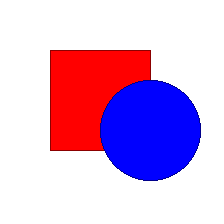

In [ ]:
img

In [ ]:
candidates = [
    'a red square and a blue elipse on white background',
    'a quartely revenue bar chart',
    'a dashboard with KPI cards',
    'a photo of dog'
]

In [ ]:
inputs = processor(text= candidates, images = img, return_tensors = 'pt', padding = True)

In [ ]:
inputs['pixel_values'].shape

torch.Size([1, 3, 224, 224])

In [ ]:
inputs

{'pixel_values': tensor([[[[1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
          [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
          [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
          ...,
          [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
          [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303],
          [1.9303, 1.9303, 1.9303,  ..., 1.9303, 1.9303, 1.9303]],

         [[2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
          [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
          [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
          ...,
          [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
          [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749],
          [2.0749, 2.0749, 2.0749,  ..., 2.0749, 2.0749, 2.0749]],

         [[2.1459, 2.1459, 2.1459,  ..., 2.1459, 2.1459, 2.1459],
          [2.1459, 2.1459, 2.1459,  ..., 2.1459, 2.1459, 2.1459],
          [2.1459, 2.1459

In [ ]:
inputs['input_ids'].shape

torch.Size([4, 13])

In [119]:
inputs['attention_mask']

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]])

In [120]:
with torch.no_grad():
  out = model(**inputs)

In [122]:
out # logits_per_image
probs = out.logits_per_image.softmax(dim=1)[0].cpu().numpy()


In [124]:
out.logits_per_image
# logits_per_images? logit이란 이미지와 텍스트(단어)간의 점수

tensor([[30.4606, 23.5285, 18.1346, 22.5753]])

In [128]:
out.logits_per_image.softmax(dim=1) # softmax 적용하여 확률 형태로 변환

tensor([[9.9865e-01, 9.7460e-04, 4.4287e-06, 3.7573e-04]])

In [123]:
for c, p in zip(candidates, probs):
  print(f" {p}, {c}")

 0.9986452460289001, a red square and a blue elipse on white background
 0.000974597001913935, a quartely revenue bar chart
 4.428669853950851e-06, a dashboard with KPI cards
 0.00037572559085674584, a photo of dog


In [130]:
# CLIP은 영어 데이터로만 학습이 되어있음 (한글 사용 X)

In [137]:
def encode_image_clip(image) -> np.ndarray:
  inputs = processor(text= candidates, images = image.convert('RGB'), return_tensors = 'pt', padding = True).to(DEVICE)
  with torch.no_grad():
    vision_out = model.vision_model(pixel_values = inputs['pixel_values'])
    pooled = vision_out.pooler_output # [1, 768]
    projected = model.visual_projection(pooled) # [1, 512]

  feat = projected[0].cpu().numpy() # [512]
  return feat / np.linalg.norm(feat) # feat / || feat ||


In [138]:
e = encode_image_clip(Image.open(IMAGE_DIR / 'shapes_red_blue.png'))

In [139]:
e.shape

(512,)

In [140]:
np.linalg.norm(e)

np.float32(1.0)

In [131]:
# clip model : image -> (1, 3, 256, 256)
#              text -> (1, 80) 1개의 텍스트, 80개의 토큰

In [ ]:
# a photo of dog
# [40406, 320, 100, 200, 40407, 40407,40407,40407....]

In [134]:
model

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [141]:
def encode_text_clip(texts) -> np.ndarray:
  inputs = processor(text=[text], return_tensors = 'pt', padding = True).to(DEVICE)
  with torch.no_grad():
    text_out = model.text_model(input_ids = inputs['input_ids'], attention_mask = inputs.get('attention_mask'))
    pooled = text_out.pooler_output
    projected = model.text_projection(pooled)

  feat = projected[0].cpu().numpy()
  return feat / np.linalg.norm(feat)

In [142]:
model

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [143]:
t = encode_text_clip('a red square and a blue elipse on white background')

NameError: name 'text' is not defined